In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls "/content/drive/MyDrive/Colab Notebooks"

ai.ipynb      CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone      practise.ipynb
cse366.ipynb  CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone.zip


In [3]:
!unzip "/content/drive/MyDrive/Colab Notebooks/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone.zip" -d "/content/dataset"

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Normal/Normal- (4364).jpg  
  inflating: /content/dataset/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Normal/Normal- (4365).jpg  
  inflating: /content/dataset/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Normal/Normal- (4366).jpg  
  inflating: /content/dataset/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Normal/Normal- (4367).jpg  
  inflating: /content/dataset/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Normal/Normal- (4368).jpg  
  inflating: /content/dataset/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Normal/Normal- (4369).jpg  
  inflating: /content/dataset/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Normal/Normal- (437).jpg  
  inflating: /content/dataset/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Normal/Normal- (4370).jpg  
  inflating: /content/dataset/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Normal/Normal- (4371).jpg  
  inflating: /content/dataset/CT-KIDNEY-DATASET-No

In [4]:
!ls /content/dataset

CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone


Found 9959 images belonging to 4 classes.
Found 2487 images belonging to 4 classes.
Epoch 1/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 96s 289ms/step - accuracy: 0.5085 - loss: 1.1558 - val_accuracy: 0.7274 - val_loss: 0.7794
Epoch 2/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 90s 288ms/step - accuracy: 0.8716 - loss: 0.3856 - val_accuracy: 0.7696 - val_loss: 0.6225
Epoch 3/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 89s 286ms/step - accuracy: 0.9486 - loss: 0.1728 - val_accuracy: 0.8134 - val_loss: 0.5112
Epoch 4/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 90s 289ms/step - accuracy: 0.9776 - loss: 0.0908 - val_accuracy: 0.7945 - val_loss: 0.5187
Epoch 5/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 90s 288ms/step - accuracy: 0.9875 - loss: 0.0583 - val_accuracy: 0.7977 - val_loss: 0.5266
Epoch 6/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 90s 289ms/step - accuracy: 0.9925 - loss: 0.0334 - val_accuracy: 0.8082 - val_loss: 0.5284
Epoch 7/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 90s 288ms/step - accuracy: 0.9961 - loss: 0.0219 - val_accuracy: 0.7969 - val_loss: 0.5033

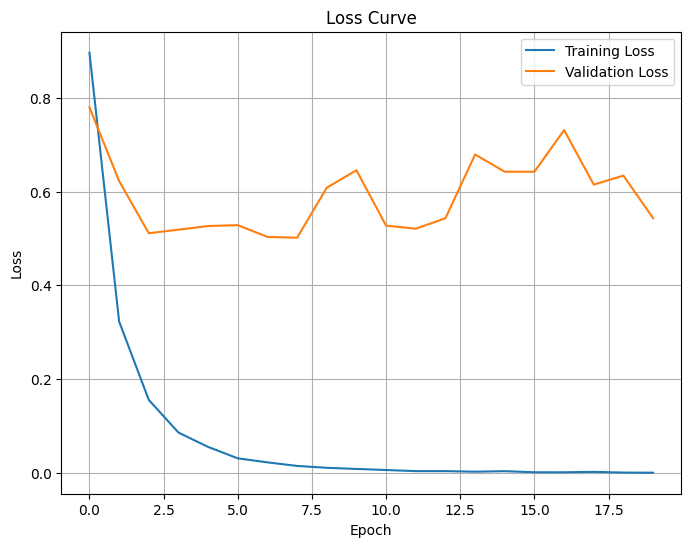

78/78 ━━━━━━━━━━━━━━━━━━━━ 17s 213ms/step


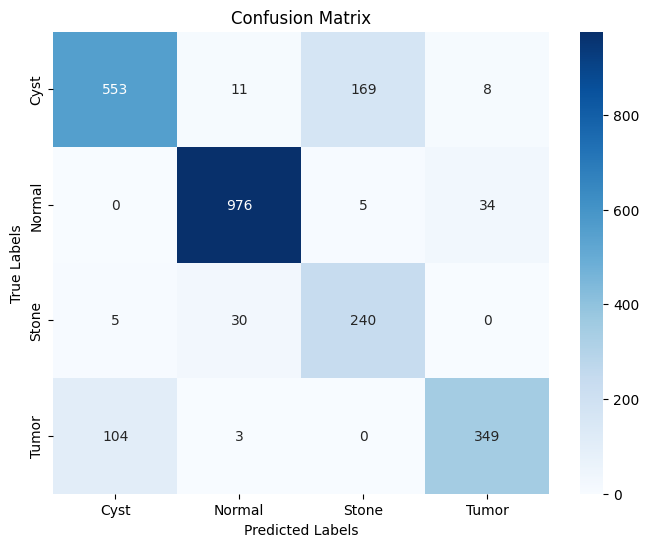

Training Time: 1809.31 seconds
Testing Time: 17.57 seconds
Confusion Matrix:
 [[553  11 169   8]
 [  0 976   5  34]
 [  5  30 240   0]
 [104   3   0 349]]
Classification Report:
               precision    recall  f1-score   support

        Cyst       0.84      0.75      0.79       741
      Normal       0.96      0.96      0.96      1015
       Stone       0.58      0.87      0.70       275
       Tumor       0.89      0.77      0.82       456

    accuracy                           0.85      2487
   macro avg       0.82      0.84      0.82      2487
weighted avg       0.87      0.85      0.85      2487

Overall Accuracy: 0.8516
Accuracy for class 'Cyst': 0.7463
Accuracy for class 'Normal': 0.9616
Accuracy for class 'Stone': 0.8727
Accuracy for class 'Tumor': 0.7654


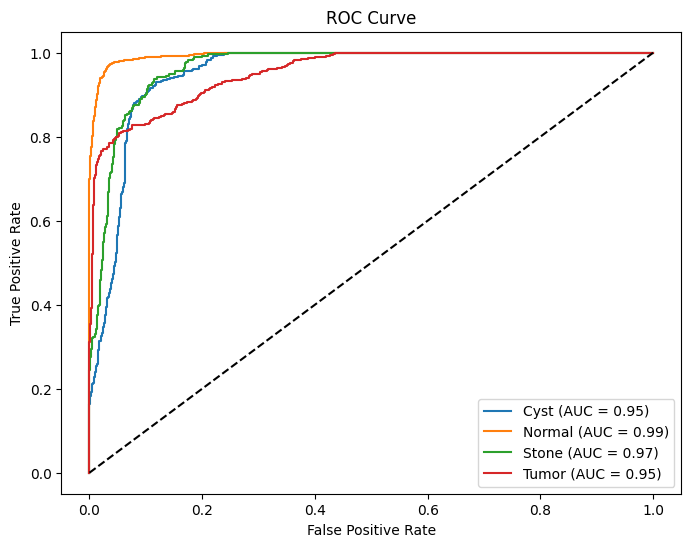

Overall Accuracy: 85.16%
Precision: 81.61%
Recall: 83.65%
F1-Score: 81.71%


In [7]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import time
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import VGG16

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 4
EPOCHS = 20
DATASET_PATH = "/content/dataset/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)


base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)


model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_train_time = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

training_time = time.time() - start_train_time

start_test_time = time.time()

y_pred_prob = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_true = val_generator.classes

testing_time = time.time() - start_test_time
class_names = list(val_generator.class_indices.keys())
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

class_report = classification_report(y_true, y_pred_classes, target_names=list(val_generator.class_indices.keys()))
accuracy = np.sum(y_pred_classes == y_true) / len(y_true)
print(f"Training Time: {training_time:.2f} seconds")
print(f"Testing Time: {testing_time:.2f} seconds")
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", class_report)
print(f"Overall Accuracy: {accuracy:.4f}")
class_accuracy = cm.diagonal() / cm.sum(axis=1)
for i, class_name in enumerate(val_generator.class_indices.keys()):
    print(f"Accuracy for class '{class_name}': {class_accuracy[i]:.4f}")
y_true_onehot = to_categorical(y_true, num_classes=NUM_CLASSES)

plt.figure(figsize=(8, 6))
for i, class_name in enumerate(val_generator.class_indices.keys()):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()


accuracy = np.sum(y_pred_classes == y_true) / len(y_true)


precision = precision_score(y_true, y_pred_classes, average='macro')
recall = recall_score(y_true, y_pred_classes, average='macro')
f1 = f1_score(y_true, y_pred_classes, average='macro')

# Print results
print(f"Overall Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"F1-Score: {f1*100:.2f}%")